<a href="https://colab.research.google.com/github/oesquivel81/Notas-proyecto-grado/blob/main/Procesamiento%20de%20datos%20y%20split.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip MaIA_Scoliosis_Dataset.zip

Archive:  MaIA_Scoliosis_Dataset.zip
   creating: MaIA_Scoliosis_Dataset/
   creating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_1.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_10.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_11.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_12.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_13.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_14.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_15.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_16.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_17.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_18.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_19.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_2.jpg  
  inflating: MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_2

In [2]:
import os
import pandas as pd
import json
from pathlib import Path

class ScoliosisDatasetManager:
    def __init__(self, root_path):
        """
        Inicializa las rutas del dataset 'MaIA_Scoliosis_Dataset'
        basado en la estructura de carpetas y el archivo index.csv.
        """
        self.root = Path(root_path)

        # Direcciones principales de imágenes (Radiografías originales)
        self.path_scoliosis = self.root / "Scoliosis"
        self.path_normal = self.root / "Normal"

        # Direcciones de etiquetas (Labels)
        self.path_labels_id = self.root / "LabelMultiClass_ID_PNG"
        self.path_labels_gray = self.root / "LabelMultiClass_Gray_JPG"
        self.path_labels_color = self.root / "LabelMultiClass_Color_JPG"
        self.path_labels_binary = self.root / "LabelBinaryJPG"

        # Archivos de metadatos
        self.path_metrics = self.root / "RadiographMetrics"
        self.path_index = self.root / "dataset_index.csv"
        self.path_dict = self.root / "labels_dictionary.json"

    def load_metadata(self):
        """Carga el índice del dataset y el diccionario de etiquetas."""
        try:
            df_index = pd.read_csv(self.path_index)
            with open(self.path_dict, 'r') as f:
                labels_dict = json.load(f)
            return df_index, labels_dict
        except FileNotFoundError as e:
            print(f"Error: Asegúrese de que los archivos .csv y .json existan. {e}")
            return None, None

    def get_full_path(self, filename, category="Scoliosis"):
        """Retorna la ruta completa de una radiografía según su categoría."""
        if category == "Scoliosis":
            return self.path_scoliosis / filename
        return self.path_normal / filename

# Ejemplo de uso
if __name__ == "__main__":
    # Define la ruta base donde descargaste el dataset
    BASE_DIR = "./MaIA_Scoliosis_Dataset"

    manager = ScoliosisDatasetManager(BASE_DIR)
    df, labels = manager.load_metadata()

    if df is not None:
        print(f"Dataset cargado con {len(df)} registros.")
        # Filtrar por pacientes con escoliosis para estimar ángulo de Cobb
        scoliosis_cases = df[df['split'] == 'Scoliosis']
        print(scoliosis_cases.head())

Dataset cargado con 250 registros.
        split     image  patient_id     radiograph_path  \
71  Scoliosis  S_21.jpg          21  Scoliosis/S_21.jpg   
72  Scoliosis  S_22.jpg          22  Scoliosis/S_22.jpg   
73  Scoliosis  S_23.jpg          23  Scoliosis/S_23.jpg   
74  Scoliosis  S_24.jpg          24  Scoliosis/S_24.jpg   
75  Scoliosis  S_25.jpg          25  Scoliosis/S_25.jpg   

                label_binary_path                           multiclass_id_png  \
71  LabelBinaryJPG/Label_S_21.jpg  LabelMultiClass_ID_PNG/LabelMulti_S_21.png   
72  LabelBinaryJPG/Label_S_22.jpg  LabelMultiClass_ID_PNG/LabelMulti_S_22.png   
73  LabelBinaryJPG/Label_S_23.jpg  LabelMultiClass_ID_PNG/LabelMulti_S_23.png   
74  LabelBinaryJPG/Label_S_24.jpg  LabelMultiClass_ID_PNG/LabelMulti_S_24.png   
75  LabelBinaryJPG/Label_S_25.jpg  LabelMultiClass_ID_PNG/LabelMulti_S_25.png   

                             multiclass_gray_jpg  \
71  LabelMultiClass_Gray_JPG/LabelMulti_S_21.jpg   
72  LabelMultiClass

In [3]:
df

,split,image,patient_id,radiograph_path,label_binary_path,multiclass_id_png,multiclass_gray_jpg,multiclass_color_jpg,metrics_json
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN
3,Normal,N_4.jpg,4,Normal/N_4.jpg,LabelBinaryJPG/Label_N_4.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_4.png,LabelMultiClass_Gray_JPG/LabelMulti_N_4.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_4.jpg,NaN
4,Normal,N_5.jpg,5,Normal/N_5.jpg,LabelBinaryJPG/Label_N_5.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_5.png,LabelMultiClass_Gray_JPG/LabelMulti_N_5.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_5.jpg,NaN
...,...,...,...,...,...,...,...,...,...
245,Scoliosis,S_202.jpg,202,Scoliosis/S_202.jpg,LabelBinaryJPG/Label_S_202.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_202.png,LabelMultiClass_Gray_JPG/LabelMulti_S_202.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_202.jpg,RadiographMetrics/metrics_json/metrics_202.json
246,Scoliosis,S_203.jpg,203,Scoliosis/S_203.jpg,LabelBinaryJPG/Label_S_203.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_203.png,LabelMultiClass_Gray_JPG/LabelMulti_S_203.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_203.jpg,RadiographMetrics/metrics_json/metrics_203.json
247,Scoliosis,S_204.jpg,204,Scoliosis/S_204.jpg,LabelBinaryJPG/Label_S_204.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_204.png,LabelMultiClass_Gray_JPG/LabelMulti_S_204.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_204.jpg,RadiographMetrics/metrics_json/metrics_204.json
248,Scoliosis,S_205.jpg,205,Scoliosis/S_205.jpg,LabelBinaryJPG/Label_S_205.jpg,LabelMultiClass_ID_PNG/LabelMulti_S_205.png,LabelMultiClass_Gray_JPG/LabelMulti_S_205.jpg,LabelMultiClass_Color_JPG/LabelMulti_S_205.jpg,RadiographMetrics/metrics_json/metrics_205.json


In [4]:
df["split"].value_counts()

,count
split,
Scoliosis,179
Normal,71


# Tarea
Preparar el conjunto de datos de radiografías de escoliosis para el entrenamiento del modelo de aprendizaje profundo. Esto incluye configurar el entorno, cargar y preprocesar las imágenes de rayos X y sus correspondientes máscaras binarias y multiclase (de `path_scoliosis`, `path_normal`, `path_labels_binary` y `path_labels_id` usando `ScoliosisDatasetManager`), visualizar imágenes y máscaras de muestra, dividir el conjunto de datos en conjuntos de entrenamiento, validación y prueba, definir una arquitectura de red neuronal (por ejemplo, U-Net o CNN) y compilar el modelo con el optimizador, la función de pérdida y las métricas adecuadas.

## Preparación del Entorno y Carga de Datos

### Subtask:
Configurar el entorno necesario e identificar los datos de imágenes y etiquetas relevantes del DataFrame 'df' para el procesamiento.


**Justificación**:
El primer paso es examinar el DataFrame `df` para comprender su estructura, centrándonos en columnas relevantes como `radiograph_path`, `label_binary_path` y `multiclass_id_png`, tal como se solicita en las instrucciones.



In [5]:
print(df.head())
print(df.columns)

    split    image  patient_id radiograph_path             label_binary_path  \
0  Normal  N_1.jpg           1  Normal/N_1.jpg  LabelBinaryJPG/Label_N_1.jpg   
1  Normal  N_2.jpg           2  Normal/N_2.jpg  LabelBinaryJPG/Label_N_2.jpg   
2  Normal  N_3.jpg           3  Normal/N_3.jpg  LabelBinaryJPG/Label_N_3.jpg   
3  Normal  N_4.jpg           4  Normal/N_4.jpg  LabelBinaryJPG/Label_N_4.jpg   
4  Normal  N_5.jpg           5  Normal/N_5.jpg  LabelBinaryJPG/Label_N_5.jpg   

                           multiclass_id_png  \
0  LabelMultiClass_ID_PNG/LabelMulti_N_1.png   
1  LabelMultiClass_ID_PNG/LabelMulti_N_2.png   
2  LabelMultiClass_ID_PNG/LabelMulti_N_3.png   
3  LabelMultiClass_ID_PNG/LabelMulti_N_4.png   
4  LabelMultiClass_ID_PNG/LabelMulti_N_5.png   

                           multiclass_gray_jpg  \
0  LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg   
1  LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg   
2  LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg   
3  LabelMultiClass_Gray_JPG/La

**Justificación**:
Basándonos en el análisis previo del DataFrame `df` y las instrucciones de la subtarea, el siguiente paso consiste en construir las rutas absolutas completas para las imágenes de radiografía, las máscaras binarias y las máscaras multiclase. Esto implica combinar la ruta `manager.root` con las rutas relativas almacenadas en las columnas `radiograph_path`, `label_binary_path` y `multiclass_id_png` del DataFrame `df`. La creación de nuevas columnas para estas rutas completas permitirá acceder a ellas fácilmente para su posterior procesamiento.


In [6]:
df['full_radiograph_path'] = manager.root / df['radiograph_path']
df['full_label_binary_path'] = manager.root / df['label_binary_path']
df['full_multiclass_id_png'] = manager.root / df['multiclass_id_png']

print(df[['image', 'full_radiograph_path', 'full_label_binary_path', 'full_multiclass_id_png']].head())

     image                   full_radiograph_path  \
0  N_1.jpg  MaIA_Scoliosis_Dataset/Normal/N_1.jpg   
1  N_2.jpg  MaIA_Scoliosis_Dataset/Normal/N_2.jpg   
2  N_3.jpg  MaIA_Scoliosis_Dataset/Normal/N_3.jpg   
3  N_4.jpg  MaIA_Scoliosis_Dataset/Normal/N_4.jpg   
4  N_5.jpg  MaIA_Scoliosis_Dataset/Normal/N_5.jpg   

                              full_label_binary_path  \
0  MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_...   
1  MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_...   
2  MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_...   
3  MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_...   
4  MaIA_Scoliosis_Dataset/LabelBinaryJPG/Label_N_...   

                              full_multiclass_id_png  
0  MaIA_Scoliosis_Dataset/LabelMultiClass_ID_PNG/...  
1  MaIA_Scoliosis_Dataset/LabelMultiClass_ID_PNG/...  
2  MaIA_Scoliosis_Dataset/LabelMultiClass_ID_PNG/...  
3  MaIA_Scoliosis_Dataset/LabelMultiClass_ID_PNG/...  
4  MaIA_Scoliosis_Dataset/LabelMultiClass_ID_PNG/...  


## Preprocesamiento de Imágenes

### Subtarea:
Cargar las imágenes de radiografías y sus correspondientes máscaras de etiquetas, y realizar operaciones de preprocesamiento.


**Justificación**:
El primer paso consiste en importar las bibliotecas necesarias, definir el tamaño de la imagen de destino y crear la función de preprocesamiento de imágenes según se especifica en las instrucciones. Esta función encapsulará la lógica para cargar, redimensionar y normalizar las imágenes y las máscaras.



In [7]:
import cv2
import numpy as np

# 2. Define un tamaño objetivo para las imágenes
IMG_SIZE = (256, 256)

# 3. Crea una función llamada preprocess_image_and_masks
def preprocess_image_and_masks(radiograph_path, binary_mask_path, multiclass_mask_path):
    """
    Carga, redimensiona y normaliza una imagen de radiografía y sus máscaras.
    """
    # a. Carga la imagen de la radiografía y ambas máscaras en escala de grises
    radiograph = cv2.imread(str(radiograph_path), cv2.IMREAD_GRAYSCALE)
    binary_mask = cv2.imread(str(binary_mask_path), cv2.IMREAD_GRAYSCALE)
    multiclass_mask = cv2.imread(str(multiclass_mask_path), cv2.IMREAD_GRAYSCALE)

    # b. Redimensiona la radiografía, la máscara binaria y la máscara multiclass al IMG_SIZE
    radiograph = cv2.resize(radiograph, IMG_SIZE, interpolation=cv2.INTER_LINEAR)
    binary_mask = cv2.resize(binary_mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    multiclass_mask = cv2.resize(multiclass_mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

    # c. Normaliza los valores de píxel de la radiografía
    radiograph = radiograph / 255.0

    # d. Convierte a arrays de NumPy de tipo float32 (radiografía) y uint8 (máscaras)
    radiograph = radiograph.astype(np.float32)
    binary_mask = binary_mask.astype(np.uint8)
    multiclass_mask = multiclass_mask.astype(np.uint8)

    # e. Devuelve la radiografía preprocesada, la máscara binaria y la máscara multiclass
    return radiograph, binary_mask, multiclass_mask

print("Libraries imported, IMG_SIZE defined, and preprocess_image_and_masks function created.")

Libraries imported, IMG_SIZE defined, and preprocess_image_and_masks function created.


**Justificación**: Siguiendo las instrucciones, seleccionaré la primera fila del DataFrame, llamaré a la función `preprocess_image_and_masks` con las rutas de la imagen y la máscara, y luego imprimiré las formas y los tipos de datos de los resultados procesados ​​para verificar la ejecución de la función.



In [8]:
first_row = df.iloc[0]

# Llama a la función preprocess_image_and_masks con las rutas completas de la primera fila
processed_radiograph, processed_binary_mask, processed_multiclass_mask = preprocess_image_and_masks(
    first_row['full_radiograph_path'],
    first_row['full_label_binary_path'],
    first_row['full_multiclass_id_png']
)

# Imprime las formas y los tipos de datos de la imagen y las máscaras resultantes
print(f"Processed Radiograph Shape: {processed_radiograph.shape}, Dtype: {processed_radiograph.dtype}")
print(f"Processed Binary Mask Shape: {processed_binary_mask.shape}, Dtype: {processed_binary_mask.dtype}")
print(f"Processed Multiclass Mask Shape: {processed_multiclass_mask.shape}, Dtype: {processed_multiclass_mask.dtype}")


Processed Radiograph Shape: (256, 256), Dtype: float32
Processed Binary Mask Shape: (256, 256), Dtype: uint8
Processed Multiclass Mask Shape: (256, 256), Dtype: uint8


**Justificación**: Ahora que la función de preprocesamiento se ha definido y probado en una sola fila, el siguiente paso es aplicarla a todas las filas del DataFrame. Esto creará nuevas columnas que contendrán las imágenes radiográficas preprocesadas, las máscaras binarias y las máscaras multiclase para todo el conjunto de datos.



In [9]:
preprocessed_data = df.apply(lambda row: preprocess_image_and_masks(
    row['full_radiograph_path'],
    row['full_label_binary_path'],
    row['full_multiclass_id_png']
), axis=1)

# Desempaquetar los resultados en columnas separadas
df['processed_radiograph'] = preprocessed_data.apply(lambda x: x[0])
df['processed_binary_mask'] = preprocessed_data.apply(lambda x: x[1])
df['processed_multiclass_mask'] = preprocessed_data.apply(lambda x: x[2])

print("Preprocessing applied to all images and masks in the DataFrame.")
print(df[['image', 'processed_radiograph', 'processed_binary_mask', 'processed_multiclass_mask']].head())

Preprocessing applied to all images and masks in the DataFrame.
     image                               processed_radiograph  \
0  N_1.jpg  [[0.16862746, 0.18431373, 0.19215687, 0.192156...   
1  N_2.jpg  [[0.14901961, 0.14901961, 0.14901961, 0.149019...   
2  N_3.jpg  [[0.17254902, 0.17254902, 0.17254902, 0.180392...   
3  N_4.jpg  [[0.78431374, 0.78431374, 0.7921569, 0.7960784...   
4  N_5.jpg  [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...   

                               processed_binary_mask  \
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
3  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   
4  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   

                           processed_multiclass_mask  
0  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  
1  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  
2  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Justificación**:
Para verificar visualmente el preprocesamiento, el siguiente paso lógico es mostrar una muestra de las radiografías procesadas y sus correspondientes máscaras binarias y multiclase. Esto ayudará a confirmar que las imágenes se han cargado, redimensionado y normalizado correctamente.



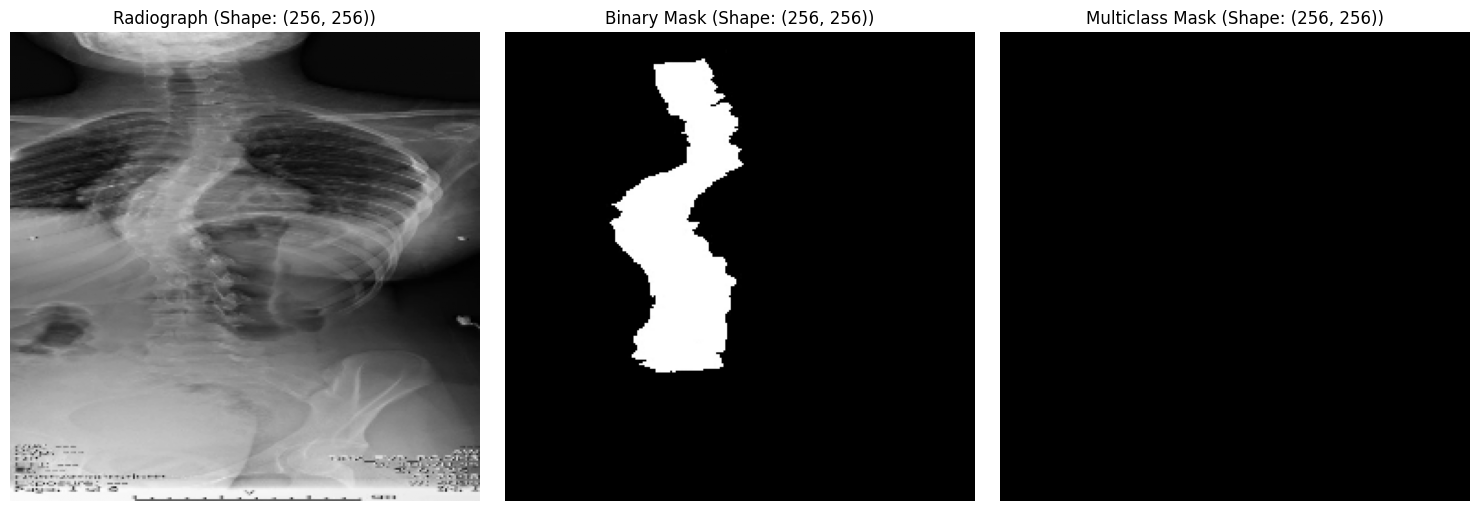

Sample image file: S_21.jpg
Radiograph Dtype: float32, Min: 0.019607843831181526, Max: 0.8666666746139526
Binary Mask Dtype: uint8, Min: 0, Max: 255
Multiclass Mask Dtype: uint8, Min: 0, Max: 0


In [10]:
import matplotlib.pyplot as plt

# Selecciona una fila de ejemplo (por ejemplo, la primera fila con imágenes de escoliosis)
# o puedes elegir cualquier otra fila del DataFrame
sample_row = df[df['split'] == 'Scoliosis'].iloc[0]

# Extrae los datos preprocesados
radiograph = sample_row['processed_radiograph']
binary_mask = sample_row['processed_binary_mask']
multiclass_mask = sample_row['processed_multiclass_mask']

# Muestra las imágenes y máscaras
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(radiograph, cmap='gray')
axes[0].set_title(f"Radiograph (Shape: {radiograph.shape})")
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray')
axes[1].set_title(f"Binary Mask (Shape: {binary_mask.shape})")
axes[1].axis('off')

axes[2].imshow(multiclass_mask, cmap='nipy_spectral') # Usa un cmap diferente para multiclass
axes[2].set_title(f"Multiclass Mask (Shape: {multiclass_mask.shape})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Sample image file: {sample_row['image']}")
print(f"Radiograph Dtype: {radiograph.dtype}, Min: {radiograph.min()}, Max: {radiograph.max()}")
print(f"Binary Mask Dtype: {binary_mask.dtype}, Min: {binary_mask.min()}, Max: {binary_mask.max()}")
print(f"Multiclass Mask Dtype: {multiclass_mask.dtype}, Min: {multiclass_mask.min()}, Max: {multiclass_mask.max()}")


## Generación de Visualizaciones de Imágenes y Máscaras

### Subtask:
Visualizar ejemplos de radiografías originales junto con sus máscaras de etiquetas binarias y/o multiclasificación para entender la calidad y características de los datos. Se incluirán leyendas para cada una de las visualizaciones generadas.


**Justificación**: Necesito seleccionar filas de muestra del DataFrame, asegurándome de que se incluyan tanto los casos "Normal" como los de "Escoliosis", para visualizar las radiografías originales y sus máscaras según las instrucciones.



In [11]:
import matplotlib.pyplot as plt
import cv2

# 1. Selecciona algunas filas de ejemplo del DataFrame
# (asegurándote de incluir al menos una radiografía 'Normal' y una de 'Scoliosis')
sample_normal = df[df['split'] == 'Normal'].iloc[0]
sample_scoliosis = df[df['split'] == 'Scoliosis'].iloc[0]

sample_rows = [sample_normal, sample_scoliosis]

print("Selected sample rows:")
print("Normal Case:")
print(sample_normal[['image', 'split']])
print("\nScoliosis Case:")
print(sample_scoliosis[['image', 'split']])

Selected sample rows:
Normal Case:
image    N_1.jpg
split     Normal
Name: 0, dtype: object

Scoliosis Case:
image     S_21.jpg
split    Scoliosis
Name: 71, dtype: object


**Justificación**: Necesito iterar sobre las filas de muestra seleccionadas, cargar la radiografía original, la máscara binaria y la máscara multiclase para cada una usando `cv2.imread()`, y luego mostrarlas usando `matplotlib.pyplot` en subgráficos según las instrucciones. Me aseguraré de usar títulos descriptivos y mapas de color apropiados.



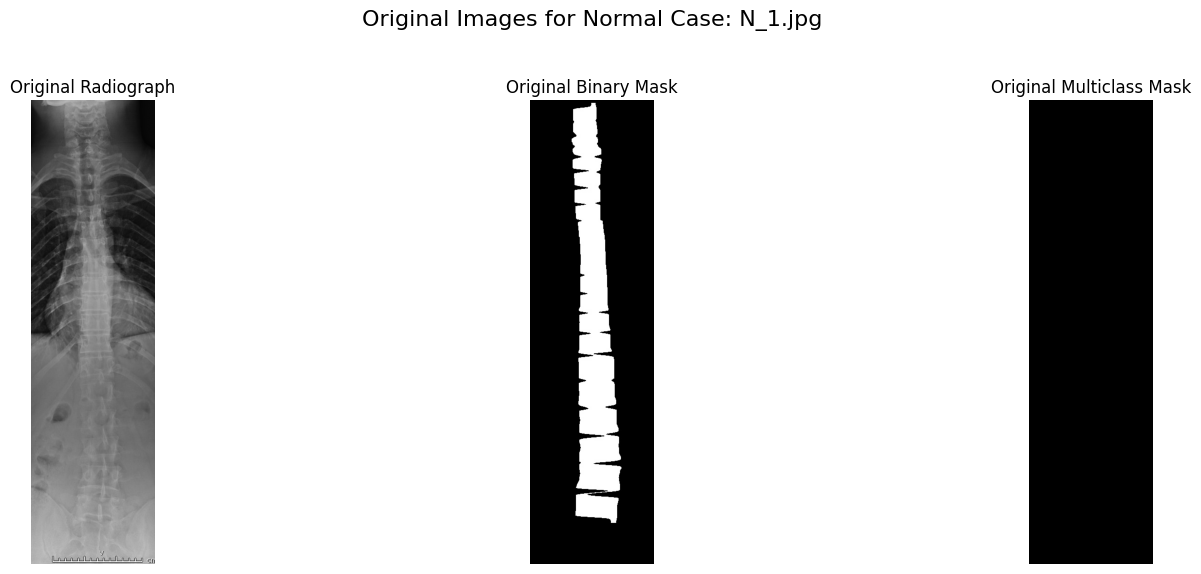

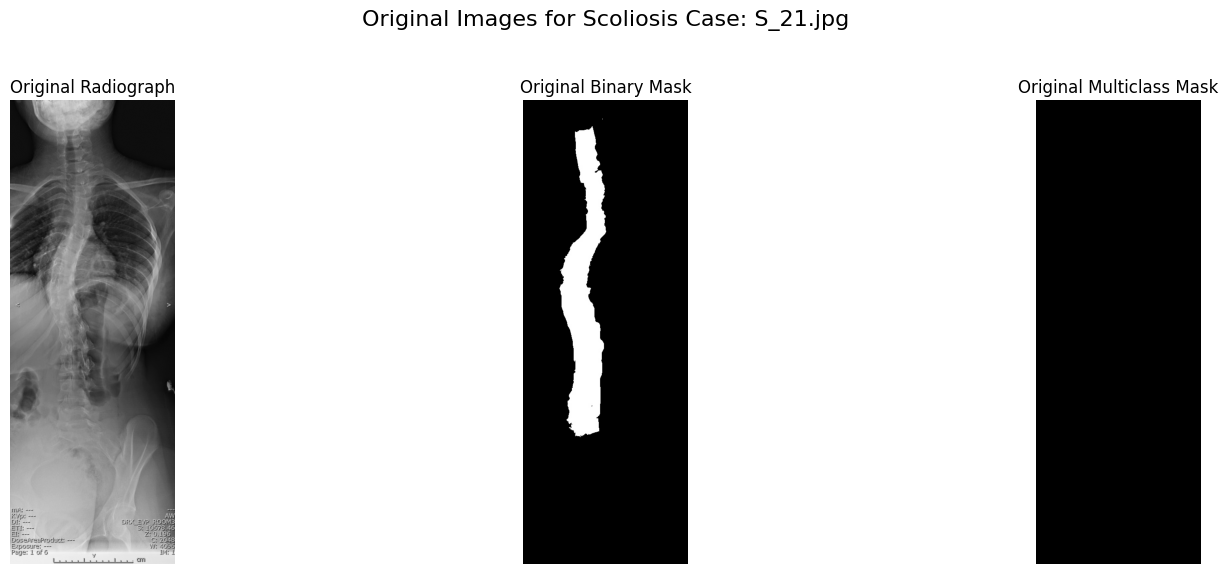

In [12]:
for i, row in enumerate(sample_rows):
    # a. Carga la imagen de la radiografía original
    radiograph_original = cv2.imread(str(row['full_radiograph_path']), cv2.IMREAD_GRAYSCALE)
    # b. Carga la máscara binaria original
    binary_mask_original = cv2.imread(str(row['full_label_binary_path']), cv2.IMREAD_GRAYSCALE)
    # c. Carga la máscara multiclass original
    multiclass_mask_original = cv2.imread(str(row['full_multiclass_id_png']), cv2.IMREAD_GRAYSCALE)

    # Obtiene el tipo de caso (Normal/Scoliosis)
    case_type = row['split']

    # 3. Utiliza matplotlib.pyplot para mostrar las imágenes y máscaras originales en subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Original Images for {case_type} Case: {row['image']}', fontsize=16)

    # Radiografía original
    axes[0].imshow(radiograph_original, cmap='gray')
    axes[0].set_title('Original Radiograph')
    axes[0].axis('off')

    # Máscara binaria original
    axes[1].imshow(binary_mask_original, cmap='gray')
    axes[1].set_title('Original Binary Mask')
    axes[1].axis('off')

    # Máscara multiclass original
    axes[2].imshow(multiclass_mask_original, cmap='nipy_spectral') # 5. Usa un cmap diferente para multiclass
    axes[2].set_title('Original Multiclass Mask')
    axes[2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para evitar solapamiento del título
    plt.show()

# Tarea
Extraer las imágenes radiográficas procesadas, las máscaras binarias y las máscaras multiclase del DataFrame en matrices NumPy separadas. Estas matrices servirán como características de entrada (X) y máscaras de destino (y_binary, y_multiclass) para el proceso posterior de división del conjunto de datos.

## Preparar datos para la división

### Subtarea:
Extraer las columnas 'processed_radiograph', 'processed_binary_mask' y 'processed_multiclass_mask' del DataFrame y convertirlas en matrices NumPy, ya que servirán como características de entrada (X) y máscaras de destino (y_binary, y_multiclass) para el proceso de división.


**Justificación**:
La subtarea requiere extraer las imágenes y máscaras procesadas a matrices NumPy y redimensionarlas para modelos de aprendizaje profundo. Este paso convertirá las columnas del DataFrame que contienen los datos de imagen y máscara a los formatos de matriz NumPy adecuados (X, y_binary, y_multiclass) y verificará sus dimensiones.



In [13]:
X = np.stack(df['processed_radiograph'].values)
y_binary = np.stack(df['processed_binary_mask'].values)
y_multiclass = np.stack(df['processed_multiclass_mask'].values)

# Reshape to add a channel dimension if it's missing (for grayscale images, channel=1)
if len(X.shape) == 3:
    X = np.expand_dims(X, axis=-1)
if len(y_binary.shape) == 3:
    y_binary = np.expand_dims(y_binary, axis=-1)
if len(y_multiclass.shape) == 3:
    y_multiclass = np.expand_dims(y_multiclass, axis=-1)

print(f"Shape of X: {X.shape}")
print(f"Shape of y_binary: {y_binary.shape}")
print(f"Shape of y_multiclass: {y_multiclass.shape}")

Shape of X: (250, 256, 256, 1)
Shape of y_binary: (250, 256, 256, 1)
Shape of y_multiclass: (250, 256, 256, 1)


## Realizar la división en conjuntos de entrenamiento y prueba

### Subtarea:
Dividir el conjunto de datos en un conjunto de entrenamiento inicial y un conjunto de prueba temporal. Se utilizará una división estratificada basada en la columna "División" (Normal/Escoliosis) para mantener la proporción de clases en cada subconjunto. Esto garantiza que tanto el conjunto de entrenamiento como el de prueba sean representativos de la distribución de clases del conjunto de datos original.


**Justificación**: La subtarea requiere dividir el conjunto de datos en conjuntos de entrenamiento y de prueba temporal, manteniendo la distribución de clases. Importaré `train_test_split`, definiré `stratify_labels` a partir de la columna 'split' del DataFrame y, a continuación, aplicaré `train_test_split` a `X`, `y_binary`, `y_multiclass` y `stratify_labels` con estratificación.


In [14]:
from sklearn.model_selection import train_test_split

# Create stratify_labels from the 'split' column
stratify_labels = df['split']

# Split the dataset into training and temporary test sets
X_train, X_test_temp, \
y_binary_train, y_binary_test_temp, \
y_multiclass_train, y_multiclass_test_temp, \
stratify_train, stratify_test_temp = train_test_split(
    X, y_binary, y_multiclass, stratify_labels,
    test_size=0.2,
    random_state=42,
    stratify=stratify_labels
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test_temp: {X_test_temp.shape}")
print(f"Shape of y_binary_train: {y_binary_train.shape}")
print(f"Shape of y_binary_test_temp: {y_binary_test_temp.shape}")
print(f"Shape of y_multiclass_train: {y_multiclass_train.shape}")
print(f"Shape of y_multiclass_test_temp: {y_multiclass_test_temp.shape}")
print(f"Stratify train distribution:\n{pd.Series(stratify_train).value_counts(normalize=True)}")
print(f"Stratify test_temp distribution:\n{pd.Series(stratify_test_temp).value_counts(normalize=True)}")

Shape of X_train: (200, 256, 256, 1)
Shape of X_test_temp: (50, 256, 256, 1)
Shape of y_binary_train: (200, 256, 256, 1)
Shape of y_binary_test_temp: (50, 256, 256, 1)
Shape of y_multiclass_train: (200, 256, 256, 1)
Shape of y_multiclass_test_temp: (50, 256, 256, 1)
Stratify train distribution:
split
Scoliosis    0.715
Normal       0.285
Name: proportion, dtype: float64
Stratify test_temp distribution:
split
Scoliosis    0.72
Normal       0.28
Name: proportion, dtype: float64


**Justificación**: El siguiente paso consiste en dividir el conjunto de prueba temporal (`X_test_temp`, `y_binary_test_temp`, `y_multiclass_test_temp`) y sus etiquetas de estratificación correspondientes (`stratify_test_temp`) en conjuntos de validación y de prueba final. Esto se realizará utilizando `train_test_split` con un `test_size` de 0,5 para dividir el conjunto temporal de forma equitativa, asegurando que tanto el conjunto de validación como el de prueba final mantengan la distribución estratificada de los casos «Normal» y «Escoliosis».



In [15]:
X_val, X_test, \
y_binary_val, y_binary_test, \
y_multiclass_val, y_multiclass_test, \
stratify_val, stratify_test = train_test_split(
    X_test_temp, y_binary_test_temp, y_multiclass_test_temp, stratify_test_temp,
    test_size=0.5, # Split the temporary test set equally into validation and test sets
    random_state=42,
    stratify=stratify_test_temp
)

print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_binary_val: {y_binary_val.shape}")
print(f"Shape of y_binary_test: {y_binary_test.shape}")
print(f"Shape of y_multiclass_val: {y_multiclass_val.shape}")
print(f"Shape of y_multiclass_test: {y_multiclass_test.shape}")
print(f"Stratify validation distribution:\n{pd.Series(stratify_val).value_counts(normalize=True)}")
print(f"Stratify test distribution:\n{pd.Series(stratify_test).value_counts(normalize=True)}")

Shape of X_val: (25, 256, 256, 1)
Shape of X_test: (25, 256, 256, 1)
Shape of y_binary_val: (25, 256, 256, 1)
Shape of y_binary_test: (25, 256, 256, 1)
Shape of y_multiclass_val: (25, 256, 256, 1)
Shape of y_multiclass_test: (25, 256, 256, 1)
Stratify validation distribution:
split
Scoliosis    0.72
Normal       0.28
Name: proportion, dtype: float64
Stratify test distribution:
split
Scoliosis    0.72
Normal       0.28
Name: proportion, dtype: float64


### Proximos pasos

Definir arquitectura de U-Net, luego a entrenar y jugar con los hiperparametros, el poder computucional se va a resolver en un momento.